## Joint Roman-Rubin HLTDS simulations for a microlensing event
This notebook demonstrates how we can simulate the Roman High Latitude Time Domain Survey (HLTDS) using files exported from APT using [LightCurveLynx](https://lightcurvelynx.readthedocs.io/en/latest/). 

Based on Roman HLTDS notebook from Mi Dai

First we need install the APT version that supports Roman (we are using Version 2025.6.3) from https://apst.stsci.edu/apt/external/downloads/APT-2025.6.3/Web/install.html

Settings -> APT settings -> STScI use only "Apt Mode checked with STScI in text box"

Now let's export a "Simulator Input" ecsv file from APT which contains pointing and exposure information. This can be done by going to File->Export in APT and select Simulator Input as shown below. (The default export file name is 'unknown.sim.ecsv') <br> <img src="figs/APT.png" width="300" height="200">

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import pandas as pd
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from regions import RectangleSkyRegion
import pickle

from lightcurvelynx.obstable.roman_obstable import RomanObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.models import bagle_models

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

Now we define necessary information for the simulation. This includes an ObsTable, which is the ecsv file we just exported. For right now we only support photometry simulation, so we drop rows for PRISM and only focus on the photometry entries. We also define a PassbandGroup from loading a preset. We append the ObsTable when initializing the RomanObsTable class to include a time column based on the survey discription in https://roman.gsfc.nasa.gov/science/High_Latitude_Time_Domain_Survey.html, which is not currently provided in the file.

In [2]:
%%time
# Load the ecsv file.
fsim = 'unknown.sim.ecsv'
with open(fsim,"r") as f:
    lines = f.read()
lines = lines.replace('no name','no_name')
apt_table = Table.read(lines, format="ascii.ecsv").to_pandas()

apt_table = apt_table.loc[apt_table.BANDPASS != "PRISM"]

# We use a rectangular detector footprint for approximation.
pixel_scale = 0.11 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
#compute an angle based on ra/dec in the table
rect_region = RectangleSkyRegion(center=center, width=49.4/60. * u.deg, 
                                 height=25.3/60. *u.deg, angle= 0. * u.deg)
fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

roman_obstable = RomanObsTable(apt_table,detector_footprint=fp)

t_min, t_max = roman_obstable.time_bounds()
print(f"Loaded ObsTable with {len(roman_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="Roman")
print(f"Loaded Passbands: {passband_group}")

Loaded ObsTable with 47931 rows and times [61406.0, 63416.5]
Loaded Passbands: PassbandGroup containing 8 passbands: Roman_F062, Roman_F087, Roman_F106, Roman_F129, Roman_F146, Roman_F158, Roman_F184, Roman_F213
CPU times: user 2.62 s, sys: 236 ms, total: 2.85 s
Wall time: 3.79 s


If needed, we can overwrite the default values of the following attributes. We show the default values here.

In [3]:
print("Survey start time:", roman_obstable.survey_values["survey_start_time"])
print("Survey cadence:", roman_obstable.survey_values["cadence"])
print("Survey component start time:", roman_obstable.survey_values["component_start_time"])
print("After component delay time:", roman_obstable.survey_values["after_component_delay_time"])

Survey start time: 61406.0
Survey cadence: {'PC': 20.0, 'EC1': 120.0, 'EC2': 120.0, 'CC': 5.0}
Survey component start time: {'North': {'PC': 61406.0, 'EC1': 61666.0, 'CC': 62126.0, 'EC2': 62936.0}, 'South': {'PC': 61406.5, 'EC1': 61666.5, 'CC': 62126.5, 'EC2': 62936.5}}
After component delay time: {'PC': 100.0, 'EC1': 100.0, 'CC': 100.0}


We can overwrite the values as the below

In [4]:
roman_obstable.survey_values["survey_start_time"] = 61436.
roman_obstable.infer_component_start_time(after_component_delay_time={"PC": 10.,
                                                                      "EC1": 10.,
                                                                      "CC": 10.,})

We can update the time column using the new values

In [5]:
roman_obstable.update_time()
print("New survey start time:", roman_obstable.survey_values["survey_start_time"])
print("New survey cadence:", roman_obstable.survey_values["cadence"])
print("New survey component start time:", roman_obstable.survey_values["component_start_time"])
print("New after component delay time:", roman_obstable.survey_values["after_component_delay_time"])

New survey start time: 61436.0
New survey cadence: {'PC': 20.0, 'EC1': 120.0, 'EC2': 120.0, 'CC': 5.0}
New survey component start time: {'North': {'PC': 61436.0, 'EC1': 61606.0, 'CC': 61976.0, 'EC2': 62696.0}, 'South': {'PC': 61436.5, 'EC1': 61606.5, 'CC': 61976.5, 'EC2': 62696.5}}
New after component delay time: {'PC': 10.0, 'EC1': 10.0, 'CC': 10.0}


Next we load in a Rubin OpSim

In [6]:
opsim_db = OpSim.from_db('/u/nsabrams/work/rubin/OpSim/baseline_v5.0.0_10yrs.db') # replace this with your desired directory and OpSim

table_dir = '/u/nsabrams/work/rubin/' # replace this with your desired directory
passband_group_rubin = PassbandGroup.from_preset(
    preset="LSST",
    units="nm",
    trim_quantile=0.001,
    delta_wave=1,
    table_dir=table_dir,
)

### We will now plot an example microlensing event in this field

For this example, we will take all the baseline magnitudes to be the same regardless of filter

In [10]:
filter_idx = {'F062':0, 'F087':1, 'F106':2, 'F129':3, 'F146':4, 'F158':5, 'F184':6, 'F213':8, 'u':9, 'g':10, 'r':11, 'i':12, 'z':13, 'y':14}

In [16]:
model_list = ['PSPL_PhotAstrom_Par_Param1']

In [29]:
param_dicts = [{'raL': np.float64(58.5),
  'decL': np.float64(-49),
  'mL': np.float64(0.2981838583946228),
  't0': 62700,
  'beta': np.float64(-0.032488965101672235),
  'dL': np.float64(3277.7187975873444),
  'dL_dS': np.float64(0.4165043662309563),
  'xS0_E': np.int64(0),
  'xS0_N': np.int64(0),
  'muL_E': np.float64(-8.28159274433332),
  'muL_N': np.float64(4.385256612215728),
  'muS_E': np.float64(-5.012720604260082),
  'muS_N': np.float64(2.2098122152236397),
  'b_sff': [np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271),
   np.float64(0.9079967233959271)],
  'mag_src': [np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548),
   np.float64(21.72666036541548)]}]

In [30]:
model = bagle_models.BagleMultiWrapperModel(
        model_list,
        param_dicts,
        in_order=True,
        node_label="model",
        filter_idx = filter_idx
    )

In [31]:
results = simulate_lightcurves(
        model=model,
        num_samples=len(model_list),
        obstable=[roman_obstable,opsim_db],
        passbands=[passband_group,passband_group_rubin],
        batch_size=100,
    )

Simulating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 22.08obj/s]


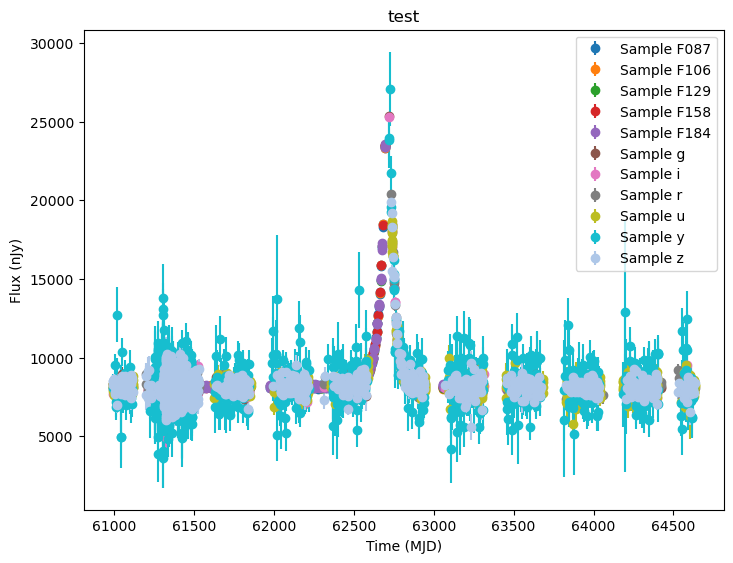

In [32]:
for idx in range(1):
    # Extract the row for this object.
    lc = results.loc[idx]

    # Plot the lightcurves.
    ax = plot_lightcurves(
        fluxes=np.asarray(lc["lightcurve"]["flux"], dtype=float),
        times=np.asarray(lc["lightcurve"]["mjd"], dtype=float),
        fluxerrs=np.asarray(lc["lightcurve"]["fluxerr"], dtype=float),
        filters=np.asarray(lc["lightcurve"]["filter"], dtype=str),
        title='test',#(f"t0={lc['t0']:.2f}, mL={lc['BagelModel_0_mL']:.2f} " f"beta={lc['BagelModel_0_beta']:.2f}"),
    )
    ax.legend()
    plt.show()